In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer
from models.bottleneck import Bottleneck

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 512,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


# consistency comparison

In [2]:
base_paths = [
    'runs/newbase/nobehav64_seed0/model_weights.pth',
    'runs/newbase/nobehav64_seed42/model_weights.pth',
    'runs/newbase/nobehav64_seed123/model_weights.pth',
]

based = []
whitened_maps = []
whitened_vecs = []
for path in base_paths:
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device);
    model.eval();

    feature_maps = []
    feature_vecs = []
    pred_resps = []
    readout_vecs = []

    for key in data_keys:
        single_maps = []
        single_vecs = []
        single_resps = []

        for batch in dataloaders['train'][key]:
            img, _, pupil = batch
            
            pred, feature_vec = model(img, data_key=key, pupil_center=pupil)
            single_resps.append(pred.detach().cpu())
            
            feature_map = model.core(img).detach().cpu()
            single_maps.append(feature_map)
            single_vecs.append(feature_vec.detach().cpu())

        feature_maps.append(torch.cat(single_maps))
        feature_vecs.append(torch.cat(single_vecs))
        pred_resps.append(torch.cat(single_resps))
        readout_vecs.append(model.readout[key]._features.detach().cpu())

    # whiten based on feature maps
    X = torch.cat(feature_maps).permute(0, 2, 3, 1).flatten(0, 2)

    # compute cov
    mu = X.mean(dim=0, keepdims=True)
    Xc = X - mu
    cov = Xc.T @ Xc / (Xc.shape[0] - 1)

    # get whitening matrix from cov
    L = torch.linalg.cholesky(cov)
    Winv = L.T
    W = Winv.inverse()

    R = torch.cat([r.squeeze() for r in readout_vecs], dim=1)
    Rw = (Winv @ R).T

    based.append(R.T)
    whitened_maps.append(Rw)

    # whiten based on feature vectors
    X = torch.cat([vecs.permute(0, 2, 3, 1).flatten(0, 2) for vecs in feature_vecs])

    # compute cov
    mu = X.mean(dim=0, keepdims=True)
    Xc = X - mu
    cov = Xc.T @ Xc / (Xc.shape[0] - 1)

    # get whitening matrix from cov
    L = torch.linalg.cholesky(cov)
    Winv = L.T
    W = Winv.inverse()

    R = torch.cat([r.squeeze() for r in readout_vecs], dim=1)
    Rw = (Winv @ R).T

    whitened_vecs.append(Rw)

In [3]:
in_dim = model_config['hidden_channels']
hidden_dims = [64]
bottleneck = Bottleneck(
    in_dim=in_dim, 
    hidden_dims=hidden_dims[:-1], 
    embedding_dim=hidden_dims[-1], 
    weight_sharing=True, 
)
for key in dataloaders['train'].keys():
    model.readout[key].bottleneck = bottleneck

bottle_paths = [
    'runs/newbottle/nocomp_seed0/model_weights.pth',
    'runs/newbottle/nocomp_seed42/model_weights.pth',
    'runs/newbottle/nocomp_seed123/model_weights.pth',
]

bottled = []
for path in bottle_paths:
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device);
    model.eval();

    combined_readout_vecs = []
    for key in data_keys:
        readout_vec = model.readout[key]._features.squeeze(2)
        readout_vec = model.readout[key].bottleneck.embed_neurons(readout_vec).detach().cpu().squeeze()
        combined_readout_vecs.append(readout_vec)
    bottled.append(torch.cat(combined_readout_vecs))

In [4]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def knn_consistency(knn1, knn2, ks):
    N, k_max = knn1.shape
    #idcs = torch.randperm(N)
    #knn2 = knn2[idcs]
    
    assert ks[-1] <= k_max 
    ranking = np.full((N, N), N, dtype=np.int32)  # Shape (N, N)
    ranking[np.arange(N)[:, None], knn1] = np.arange(k_max)[None]
    overlaps = []

    for k in ks:
        neighbours = knn2[:, :k]  # Shape (N, k)
        shared = ranking[np.arange(N)[:, None], neighbours] < k  # Shape (N, k)
        num_shared = shared.sum() / N
        
        overlap = num_shared / k
        overlaps.append(overlap)

    return np.array(overlaps)

def get_curve(k_range, all_features):
    knns = []
    for features in all_features:
        nn = NearestNeighbors(n_neighbors=k_range[-1]).fit(features)
        knn = nn.kneighbors(return_distance=False)
        knns.append(knn)

    #for leniency in leniency_range:
    x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
    constistencies = []
    for x, y in zip(x_idcs, y_idcs):
        constistencies.append(knn_consistency(knns[x], knns[y], ks=k_range))
    constistencies = np.column_stack(constistencies)

    mean_curve = constistencies.mean(axis=1)
    std_curve = constistencies.std(axis=1, ddof=1)

    return mean_curve, std_curve

def get_ari_curve(n_clusters_range, all_features):
    def cluster(points, n_clusters):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels = kmeans.fit_predict(points)
        return labels
    
    mean_curve = []
    std_curve = []
    for n in n_clusters_range:
        labels = [cluster(features, n) for features in all_features]

        x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
        aris = np.array([
            adjusted_rand_score(labels[x], labels[y]) for x, y in zip(x_idcs, y_idcs)
        ])

        ari_mean = aris.mean()
        ari_std = aris.std(ddof=1)
        mean_curve.append(ari_mean)
        std_curve.append(ari_std)
    
    return mean_curve, std_curve

In [5]:
k_range = np.unique(np.geomspace(1, 100, num=20, dtype=int))
knn_curves = [
    #get_curve(k_range, based),
    get_curve(k_range, bottled),
    get_curve(k_range, whitened_maps), 
    get_curve(k_range, whitened_vecs),
]

In [6]:
n_clusters_range = np.unique(np.geomspace(5, 90, num=20, dtype=int))
ari_curves = [
    #get_ari_curve(n_clusters_range, based),
    get_ari_curve(n_clusters_range, bottled),
    get_ari_curve(n_clusters_range, whitened_maps),
    get_ari_curve(n_clusters_range, whitened_vecs),
]

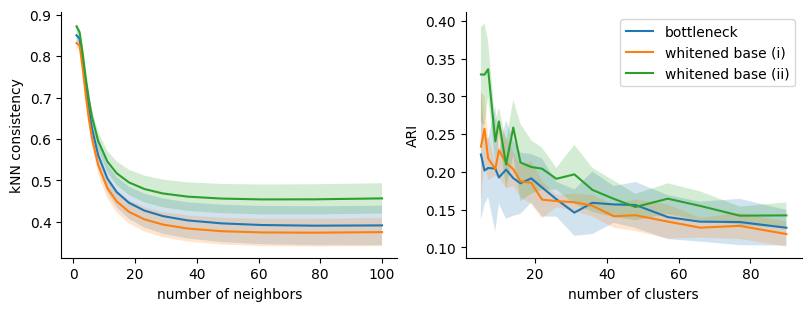

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Expect:
# knn_curves_mean, knn_curves_std: list/array of shape (n_labels, len(k_range))
# ari_curves_mean, ari_curves_std: list/array of shape (n_labels, len(n_clusters_range))

labels = ['bottleneck', 'whitened base (i)', 'whitened base (ii)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)

# ---- KNN consistency (mean ± std) ----
for i, label in enumerate(labels):
    m = np.asarray(knn_curves[i][0])
    s = np.asarray(knn_curves[i][1])
    ax1.plot(k_range, m, label=label)
    ax1.fill_between(k_range, m - s, m + s, alpha=0.2)

ax1.set_xlabel('number of neighbors')
ax1.set_ylabel('kNN consistency')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
#ax1.legend(title='')

# ---- ARI (mean ± std) ----
for i, label in enumerate(labels):
    m = np.asarray(ari_curves[i][0])
    s = np.asarray(ari_curves[i][1])
    ax2.plot(n_clusters_range, m, label=label)
    ax2.fill_between(n_clusters_range, m - s, m + s, alpha=0.2)

ax2.set_xlabel('number of clusters')
ax2.set_ylabel('ARI')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(title='')

plt.savefig('plots/result_bottleneck_vs_whitening.pdf')
plt.show()

# readout-picked feature vec whitening comparison

In [8]:
path = bottle_paths[0]
model.load_state_dict(torch.load(path, map_location=device))
model.to(device);
model.eval();

feature_vecs = []

for key in data_keys:
    single_vecs = []

    for batch in dataloaders['validation'][key]:
        img, _, pupil = batch
        
        pred, feature_vec = model(img, data_key=key, pupil_center=pupil)
        single_vecs.append(feature_vec.detach().cpu())

    feature_vecs.append(torch.cat(single_vecs))

In [9]:
feature_vecs = torch.cat([f.flatten(0, 1) for f in feature_vecs])

In [10]:
X = feature_vecs
barlow_cov = X.T @ X / (X.shape[0] - 1)

In [ ]:
path = base_paths[0]
for key in data_keys:
    model.readout[key].bottleneck = None
model.load_state_dict(torch.load(path, map_location=device))
model.to(device);
model.eval();

feature_maps = []
feature_vecs = []

for key in data_keys:
    single_maps = []
    single_vecs = []

    for batch in dataloaders['validation'][key]:
        img, _, pupil = batch
        
        pred, feature_vec = model(img, data_key=key, pupil_center=pupil)
        
        feature_map = model.core(img).detach().cpu()
        single_maps.append(feature_map)
        single_vecs.append(feature_vec.detach().cpu())

    feature_maps.append(torch.cat(single_maps))
    feature_vecs.append(torch.cat(single_vecs))

# whiten based on feature maps
X = torch.cat(feature_maps).permute(0, 2, 3, 1).flatten(0, 2)

# compute cov
mu = X.mean(dim=0, keepdims=True)
Xc = X - mu
cov = Xc.T @ Xc / (Xc.shape[0] - 1)

# get whitening matrix from cov
L = torch.linalg.cholesky(cov)
Winv = L.T
W = Winv.inverse()

In [30]:
w = (torch.cat(feature_maps).permute(0, 2, 3, 1).flatten(0, 2) - mu) @ W

In [31]:
feature_vecs = torch.cat([f.squeeze().permute(0, 2, 1).flatten(0, 1) for f in feature_vecs])
whitened_vecs = (feature_vecs - mu) @ W

X = whitened_vecs
whitened_cov = X.T @ X / (X.shape[0] - 1)

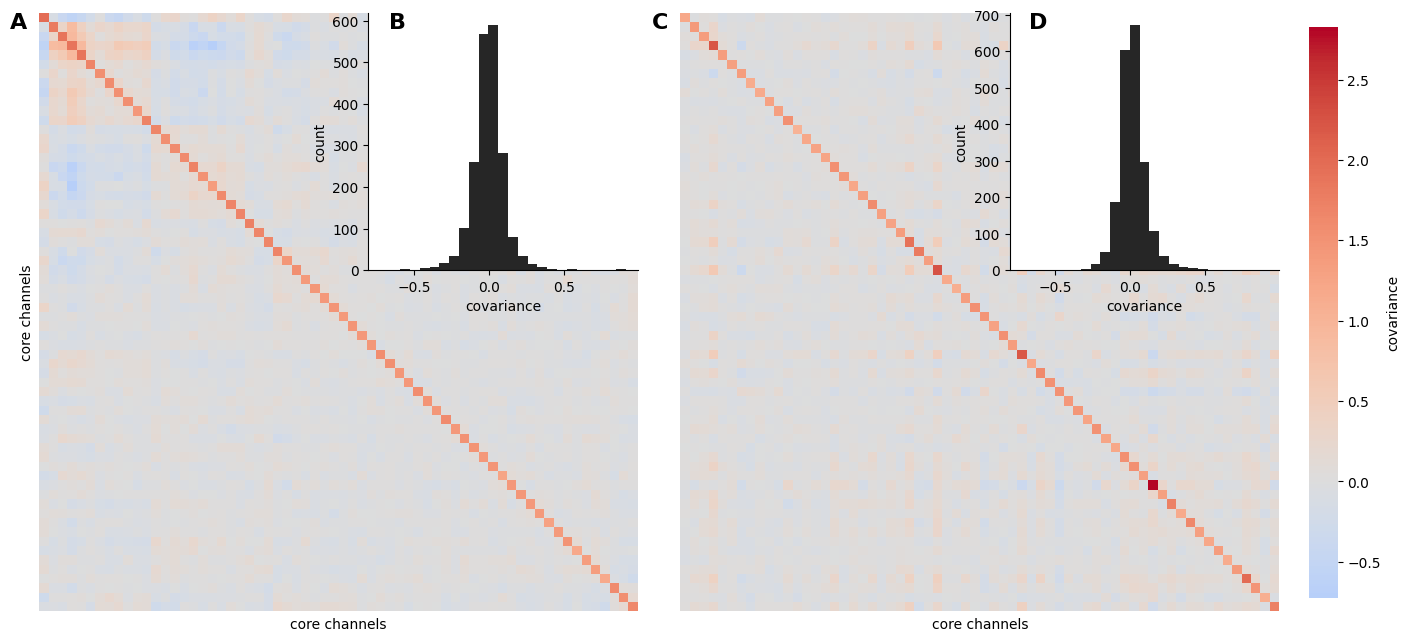

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# cov1, cov2: your two covariance matrices (square, same shape)
cov1 = barlow_cov
cov2 = whitened_cov

# --- Optional: use ONE common clustering order (based on cov1) ---
cg = sns.clustermap(cov1)
order = cg.dendrogram_row.reordered_ind
plt.close(cg.fig)

cov1o = np.asarray(cov1)[order][:, order]
cov2o = np.asarray(cov2)[order][:, order]

# --- Shared color scale across both heatmaps ---
vmin = min(cov1o.min(), cov2o.min())
vmax = max(cov1o.max(), cov2o.max())

# --- Shared histogram bins across both insets ---
vals1 = cov1o[np.tril_indices(cov1o.shape[0], k=-1)]
vals2 = cov2o[np.tril_indices(cov2o.shape[0], k=-1)]
all_vals = np.concatenate([vals1, vals2])
bins = np.histogram_bin_edges(all_vals, bins=25)  # or give an int / custom edges

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)

# Heatmap 1 (no colorbar)
sns.heatmap(
    cov1o, ax=axes[0], cmap="coolwarm", center=0, square=True,
    vmin=vmin, vmax=vmax, cbar=False, xticklabels=False, yticklabels=False
)
axes[0].set_xlabel("core channels"); axes[0].set_ylabel("core channels")
axes[0].text(-0.02, 1, "A", transform=axes[0].transAxes,
             fontsize=16, fontweight="bold", va="top", ha="right")

# Heatmap 2 (with shared colorbar)
hm2 = sns.heatmap(
    cov2o, ax=axes[1], cmap="coolwarm", center=0, square=True,
    vmin=vmin, vmax=vmax, cbar=True, cbar_kws={"shrink": 0.9},
    xticklabels=False, yticklabels=False
)
axes[1].set_xlabel("core channels"); axes[1].set_ylabel("")
hm2.figure.axes[-1].set_ylabel("covariance")
axes[1].text(-0.02, 1, "C", transform=axes[1].transAxes,
             fontsize=16, fontweight="bold", va="top", ha="right")

# Inset histograms (same bins)
for ax, vals, label in [(axes[0], vals1, "B"), (axes[1], vals2, "D")]:
    axins = inset_axes(ax, width="45%", height="43%", loc="upper right", borderpad=0)
    axins.hist(vals, bins=bins, color="black", alpha=0.85)
    axins.set_xlabel("covariance")
    axins.set_ylabel("count")
    axins.text(0.14, 1, label, transform=axins.transAxes,
               fontsize=16, fontweight="bold", va="top", ha="right")
    axins.spines["top"].set_visible(False)
    axins.spines["right"].set_visible(False)

plt.savefig("plots/two_cov_side_by_side.pdf")
plt.show()

# train/val split whitening

In [21]:
for key in data_keys:
    model.readout[key].bottleneck = None

base_paths = [
    'runs/newbase/nobehav64_seed0/model_weights.pth',
    'runs/newbase/nobehav64_seed42/model_weights.pth',
    'runs/newbase/nobehav64_seed123/model_weights.pth',
]

model.load_state_dict(torch.load(base_paths[0], map_location=device))
model.to(device);
model.eval();

feature_maps = []
# pred_resps = []
# readout_vecs = []

for key in data_keys:
    single_maps = []
    # single_vecs = []
    # single_resps = []

    for batch in dataloaders['train'][key]:
        img, _, pupil = batch
        
        pred, feature_vec = model(img, data_key=key, pupil_center=pupil)
        # single_resps.append(pred.detach().cpu())
        
        feature_map = model.core(img).detach().cpu()
        single_maps.append(feature_map)
        # single_vecs.append(feature_vec.detach().cpu())

    feature_maps.append(torch.cat(single_maps))
    # feature_vecs.append(torch.cat(single_vecs))
    # pred_resps.append(torch.cat(single_resps))
    # readout_vecs.append(model.readout[key]._features.detach().cpu())

# whiten based on feature maps
X_train = torch.cat(feature_maps).permute(0, 2, 3, 1).flatten(0, 2)

# compute cov
mu = X_train.mean(dim=0, keepdims=True)
Xc = X_train - mu
cov = Xc.T @ Xc / (Xc.shape[0] - 1)

# get whitening matrix from cov
L = torch.linalg.cholesky(cov)
Winv = L.T
W = Winv.inverse()

feature_maps = []

for key in data_keys:
    single_maps = []

    for batch in dataloaders['validation'][key]:
        img, _, pupil = batch
        
        pred, feature_vec = model(img, data_key=key, pupil_center=pupil)
        
        feature_map = model.core(img).detach().cpu()
        single_maps.append(feature_map)

    feature_maps.append(torch.cat(single_maps))

X_val = torch.cat(feature_maps).permute(0, 2, 3, 1).flatten(0, 2)

Xw = (X_val - mu) @ W

In [23]:
cov_w = Xw.T @ Xw / (Xw.shape[0] - 1)

In [ ]:
in_dim = model_config['hidden_channels']
hidden_dims = [64]
bottleneck = Bottleneck(
    in_dim=in_dim, 
    hidden_dims=hidden_dims[:-1], 
    embedding_dim=hidden_dims[-1], 
    weight_sharing=True, 
)
for key in dataloaders['train'].keys():
    model.readout[key].bottleneck = bottleneck

path = bottle_paths[0]
model.load_state_dict(torch.load(path, map_location=device))
model.to(device);
model.eval();

feature_vecs = []

for key in data_keys:
    single_vecs = []

    for batch in dataloaders['validation'][key]:
        img, _, pupil = batch
        
        pred, feature_vec = model(img, data_key=key, pupil_center=pupil)
        single_vecs.append(feature_vec.detach().cpu())

    feature_vecs.append(torch.cat(single_vecs))

In [44]:
in_dim = model_config['hidden_channels']
hidden_dims = [64]
bottleneck = Bottleneck(
    in_dim=in_dim, 
    hidden_dims=hidden_dims[:-1], 
    embedding_dim=hidden_dims[-1], 
    weight_sharing=True, 
)
for key in dataloaders['train'].keys():
    model.readout[key].bottleneck = bottleneck

bottle_paths = [
    'runs/newbottle/nocomp_seed0/model_weights.pth',
    'runs/newbottle/nocomp_seed42/model_weights.pth',
    'runs/newbottle/nocomp_seed123/model_weights.pth',
]

bottle_maps = []

model.load_state_dict(torch.load(bottle_paths[0], map_location=device))
model.to(device);
model.eval();

feature_maps = []
for key in data_keys:
    for batch in dataloaders['validation'][key]:
        img, _, pupil = batch
        _ = model(img, data_key=key, pupil_center=pupil)

        feature_map, _ = model.readout[key].bottleneck.get_last_embeds()
        feature_maps.append(feature_map.detach().cpu())
bottle_maps = torch.cat(feature_maps)

In [49]:
X = bottle_maps.permute(0, 2, 3, 1).flatten(0, 2)

Xc = X - X.mean(dim=0, keepdim=True)
cov_b = Xc.T @ Xc / (Xc.shape[0] - 1)

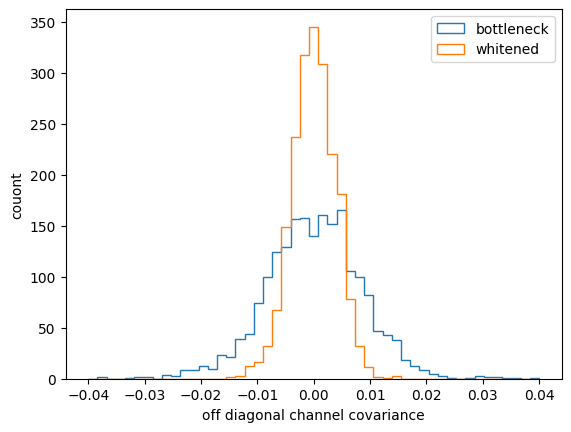

In [73]:
i, j = torch.tril_indices(*cov_w.shape, offset=-1)
offdiag_w = cov_w[i, j]
offdiag_b = cov_b[i, j]
bins = torch.linspace(-0.04, 0.04, 50)
plt.hist(offdiag_b, bins=bins, histtype='step', label='bottleneck')
plt.hist(offdiag_w, bins=bins, histtype='step', label='whitened')
plt.xlabel('off diagonal channel covariance')
plt.ylabel('couont')
plt.legend()
plt.show()